# A field name is not a string

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/automation-suite/header-casing/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=automation-suite/header-casing/demo.ipynb)

`headers["Content-Type"]` is the wrong shape, and not for style reasons.

> **RFC 9110 5.1** - field names are case-insensitive.
> **RFC 9113 8.2.1** - in HTTP/2 field names MUST be lowercase, and a message
> containing an uppercase field name MUST be treated as malformed.

Those two sentences together mean the spelling that reaches your handler is a
property of the **path** the message took, not of the code that sent it. A
dictionary keyed by the name as typed disagrees with HTTP twice: it holds two
entries for one field, and one entry for two field lines HTTP keeps separate.

This notebook builds the audit from nothing:

1. the five spelling rules that ship in real stacks, and the one that is a bug
2. eight hops - HTTP/2, nginx, CGI, Go, Node, a `Dict[str, str]`, a Turkish locale
3. four verdicts over a whole path: `preserved`, `renormalized`, `lossy`, `rejected`
4. three exhaustive searches over 86 field names
5. the lookup matrix: which line of application code still finds the field
6. a chart, and a check against the numbers this repo publishes

Everything is standard library plus matplotlib. Nothing is imported from the repo,
so the agreement at the end means something.

## 1. Five ways to spell one field name

All five of these ship somewhere. Only the first two are rules about *identity*;
the rest are rules about *presentation* that end up deciding identity by accident.

| function | who does it |
|---|---|
| `ascii_lower` | HTTP/2, HTTP/3, AWS SigV4 canonical requests, Node `req.headers` |
| `go_canonical` | Go `net/http`, Python's `email` package |
| `py_title` | `str.title()`, reached for when `go_canonical` was meant |
| `wsgi_key` | CGI, WSGI, PHP `$_SERVER` (PEP 3333, RFC 3875 4.1.18) |
| `turkish_lower` | Java `toLowerCase()` with no `Locale.ROOT`, on a `tr_TR` machine |

In [1]:
from __future__ import annotations

import re
from typing import Dict, List, Optional, Sequence, Tuple

# RFC 9110 5.6.2: field-name = token = 1*tchar. Note that "_" is a tchar.
TOKEN_RE = re.compile(r"^[!#$%&'*+\-.^_`|~0-9A-Za-z]+$")

_ASCII_LOWER = {ord(c): ord(c) + 32 for c in "ABCDEFGHIJKLMNOPQRSTUVWXYZ"}
_TR_LOWER = dict(_ASCII_LOWER)
_TR_LOWER[ord("I")] = 0x131  # LATIN SMALL LETTER DOTLESS I


def is_token(name: str) -> bool:
    return bool(TOKEN_RE.match(name))


def ascii_lower(s: str) -> str:
    """Lowercase the ASCII letters and nothing else - the only correct rule."""
    return s.translate(_ASCII_LOWER)


def turkish_lower(s: str) -> str:
    return s.translate(_TR_LOWER)


def go_canonical(name: str) -> str:
    """Uppercase the first letter and each letter after a hyphen; lowercase the rest.

    Go returns the name unchanged when it is not a legal token, so the guard is
    part of the rule.
    """
    if not is_token(name):
        return name
    out, upper = [], True
    for ch in name:
        if upper and "a" <= ch <= "z":
            out.append(chr(ord(ch) - 32))
        elif not upper and "A" <= ch <= "Z":
            out.append(chr(ord(ch) + 32))
        else:
            out.append(ch)
        upper = ch == "-"
    return "".join(out)


def py_title(name: str) -> str:
    return name.title()


def wsgi_key(name: str) -> str:
    return "HTTP_" + name.upper().replace("-", "_")


print(f"{'name':<20}{'ascii_lower':<20}{'canonical':<20}{'title()':<20}cgi")
for n in ("ETag", "WWW-Authenticate", "Content-MD5", "X-2FA-Token", "TE", "If-Match"):
    print(f"{n:<20}{ascii_lower(n):<20}{go_canonical(n):<20}{py_title(n):<20}"
          f"{wsgi_key(n)}")

print()
print("str.title() capitalises after a digit; the canonical rule only after a hyphen:")
print(f"  x-2fa-token -> title(): {py_title('x-2fa-token')}   "
      f"canonical: {go_canonical('x-2fa-token')}")
print()
print("and a locale-sensitive lowercase produces something that is not a field name:")
print(f"  If-Match -> {turkish_lower('If-Match')!r}  is_token: "
      f"{is_token(turkish_lower('If-Match'))}")

name                ascii_lower         canonical           title()             cgi
ETag                etag                Etag                Etag                HTTP_ETAG
WWW-Authenticate    www-authenticate    Www-Authenticate    Www-Authenticate    HTTP_WWW_AUTHENTICATE
Content-MD5         content-md5         Content-Md5         Content-Md5         HTTP_CONTENT_MD5
X-2FA-Token         x-2fa-token         X-2fa-Token         X-2Fa-Token         HTTP_X_2FA_TOKEN
TE                  te                  Te                  Te                  HTTP_TE
If-Match            if-match            If-Match            If-Match            HTTP_IF_MATCH

str.title() capitalises after a digit; the canonical rule only after a hyphen:
  x-2fa-token -> title(): X-2Fa-Token   canonical: X-2fa-Token

and a locale-sensitive lowercase produces something that is not a field name:
  If-Match -> 'ıf-match'  is_token: False


## 2. A message is an ordered list of lines, not a mapping

Two things a `Dict[str, str]` cannot hold: **order**, and **duplicates**. Both are
part of the message. `Set-Cookie` may appear many times in one response and must
not be joined with commas (RFC 9110 5.3), because its own value contains commas
in the `Expires` date.

In [2]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Field:
    name: str   # as spelled on the wire
    value: str

    @property
    def key(self) -> str:
        """The field's identity. ASCII-lowercased, never locale-lowercased."""
        return ascii_lower(self.name)


@dataclass(frozen=True)
class Message:
    name: str
    fields: Tuple[Field, ...]

    @property
    def keys(self) -> Tuple[str, ...]:
        return tuple(f.key for f in self.fields)

    def identity(self) -> Tuple[Tuple[str, str], ...]:
        """What the message *means*: identities and values, order kept."""
        return tuple((f.key, f.value.strip()) for f in self.fields)

    def show(self) -> str:
        return "\n".join(f"  {f.name}: {f.value}" for f in self.fields)


def mk(name: str, *pairs: Tuple[str, str]) -> Message:
    return Message(name, tuple(Field(n, v) for n, v in pairs))


demo = mk("mixed-spelling", ("X-Api-Key", "k1"), ("X-API-KEY", "k2"), ("Accept", "*/*"))
print(demo.show())
print()
print("distinct field identities:", len(set(demo.keys)))
print("distinct spellings:      ", len({f.name for f in demo.fields}))
print("\nRFC 9110 5.1 says two of these lines are one field. A dict keyed by the")
print("name as received says they are two, and every lookup finds at most one.")

  X-Api-Key: k1
  X-API-KEY: k2
  Accept: */*

distinct field identities: 2
distinct spellings:       3

RFC 9110 5.1 says two of these lines are one field. A dict keyed by the
name as received says they are two, and every lookup finds at most one.


## 3. Eight hops, and what each is allowed to do

Each hop takes a message and returns the message that came out, or `None` if a
conforming implementation must treat it as malformed. Every rule below is a
documented one, not an invention:

* **h2-encode** - RFC 9113 8.2.1 lowercases every name; 8.2.2 makes a
  connection-specific field (`Connection`, `Keep-Alive`, `Transfer-Encoding`,
  `Upgrade`, and `TE` with any value but `trailers`) malformed
* **h2-receiver** - a receiver seeing an uppercase byte in a name must treat the
  message as malformed
* **nginx** - `underscores_in_headers off` is the default; a name containing `_`
  is dropped, silently
* **cgi** - `HTTP_` + uppercase with `-` replaced by `_`, so two distinct legal
  names land on one variable
* **go** - canonical spelling, and `Header.Write` emits keys sorted, because
  `http.Header` is a map
* **node** - `req.headers` lowercases, arrays `set-cookie`, joins `cookie` with
  `"; "`, **discards** duplicates of 19 named fields, joins the rest with `", "`
* **app-dict** - `Dict[str, str]`: last write wins, and one field can occupy two
  entries
* **locale** - `tolower` with the platform locale, on a machine set to `tr_TR`

In [3]:
H2_FORBIDDEN = {"connection", "proxy-connection", "keep-alive",
                "transfer-encoding", "upgrade", "te"}

NODE_DISCARD_DUPES = {
    "age", "authorization", "content-length", "content-type", "etag", "expires",
    "from", "host", "if-modified-since", "if-unmodified-since", "last-modified",
    "location", "max-forwards", "proxy-authorization", "referer", "retry-after",
    "server", "user-agent",
}

Event = Tuple[str, str, str]  # (hop, code, detail)


def h2_encode(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev: List[Event] = []
    for f in m.fields:
        if f.key in H2_FORBIDDEN and not (f.key == "te" and f.value.strip() == "trailers"):
            return None, [("h2-encode", "h2-forbidden-field",
                           f"{f.name!r} is connection-specific (RFC 9113 8.2.2)")]
        if not is_token(f.name):
            return None, [("h2-encode", "not-a-token", f"{f.name!r} is not a token")]
    out = []
    for f in m.fields:
        low = ascii_lower(f.name)
        if low != f.name:
            ev.append(("h2-encode", "lowercased", f"{f.name!r} -> {low!r}"))
        out.append(Field(low, f.value))
    return Message(m.name, tuple(out)), ev


def h2_receiver(m: Message) -> Tuple[Optional[Message], List[Event]]:
    for f in m.fields:
        if any("A" <= c <= "Z" for c in f.name):
            return None, [("h2-receiver", "malformed-uppercase",
                           f"{f.name!r} has an uppercase byte (RFC 9113 8.2.1)")]
    return m, []


def nginx(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev, out = [], []
    for f in m.fields:
        if "_" in f.name:
            ev.append(("nginx", "dropped-underscore", f"{f.name!r} dropped silently"))
        else:
            out.append(f)
    return Message(m.name, tuple(out)), ev


def cgi(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev, order, bucket = [], [], {}
    for f in m.fields:
        k = wsgi_key(f.name)
        bucket.setdefault(k, []).append(f)
        if k not in order:
            order.append(k)
    out = []
    for k in order:
        group = bucket[k]
        if len({f.key for f in group}) > 1:
            ev.append(("cgi", "environ-collision",
                       f"{sorted({f.name for f in group})} share {k}"))
        elif len(group) > 1:
            ev.append(("cgi", "joined-duplicates",
                       f"{len(group)} lines of {group[0].key!r} joined with ', '"))
        out.append(Field(k, ", ".join(f.value for f in group)))
    return Message(m.name, tuple(out)), ev


def go(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev, out = [], []
    for f in m.fields:
        c = go_canonical(f.name)
        if c != f.name:
            ev.append(("go", "canonicalised", f"{f.name!r} -> {c!r}"))
        out.append(Field(c, f.value))
    ordered = sorted(out, key=lambda f: f.name)
    if [f.name for f in ordered] != [f.name for f in out]:
        ev.append(("go", "reordered", "Header.Write emits keys sorted"))
    return Message(m.name, tuple(ordered)), ev


def node(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev, order, bucket = [], [], {}
    for f in m.fields:
        bucket.setdefault(f.key, []).append(f)
        if f.key not in order:
            order.append(f.key)
        if f.key != f.name:
            ev.append(("node", "lowercased",
                       f"req.headers key is {f.key!r}, the wire said {f.name!r}"))
    out = []
    for k in order:
        group = bucket[k]
        if k == "set-cookie":
            out.extend(Field(k, f.value) for f in group)
        elif len(group) > 1 and k in NODE_DISCARD_DUPES:
            ev.append(("node", "discarded-duplicate",
                       f"{len(group) - 1} further {k!r} line(s) thrown away"))
            out.append(Field(k, group[0].value))
        elif len(group) > 1:
            sep = "; " if k == "cookie" else ", "
            ev.append(("node", "joined-duplicates",
                       f"{len(group)} lines of {k!r} joined with {sep!r}"))
            out.append(Field(k, sep.join(f.value for f in group)))
        else:
            out.append(Field(k, group[0].value))
    return Message(m.name, tuple(out)), ev


def app_dict(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev, seen = [], {}
    for f in m.fields:
        if f.name in seen:
            ev.append(("app-dict", "last-write-wins",
                       f"a second {f.name!r} overwrote {seen[f.name].value!r}"))
        seen[f.name] = f
    by_key = {}
    for name in seen:
        by_key.setdefault(ascii_lower(name), []).append(name)
    for key, names in by_key.items():
        if len(names) > 1:
            ev.append(("app-dict", "split-identity",
                       f"one field {key!r} occupies {len(names)} entries: "
                       f"{sorted(names)}"))
    return Message(m.name, tuple(seen.values())), ev


def locale(m: Message) -> Tuple[Optional[Message], List[Event]]:
    ev, out = [], []
    for f in m.fields:
        low = turkish_lower(f.name)
        if low != ascii_lower(f.name):
            ev.append(("locale", "turkish-dotless-i",
                       f"{f.name!r} -> {low!r}, not {ascii_lower(f.name)!r}"))
        out.append(Field(low, f.value))
    return Message(m.name, tuple(out)), ev


HOPS = {"h2-encode": h2_encode, "h2-receiver": h2_receiver, "nginx": nginx,
        "cgi": cgi, "go": go, "node": node, "app-dict": app_dict, "locale": locale}

PATHS = {
    "direct-h1": (),
    "h2-gateway": ("h2-encode",),
    "nginx-h1": ("nginx",),
    "h1-to-dict": ("app-dict",),
    "h2-then-go": ("h2-encode", "go"),
    "nginx-to-cgi": ("nginx", "cgi"),
    "h2-to-node": ("h2-encode", "node"),
    "h2-to-node-to-dict": ("h2-encode", "node", "app-dict"),
    "handwritten-h2-frame": ("h2-receiver",),
    "java-tr-locale": ("locale", "app-dict"),
}
print(f"{len(HOPS)} hops, {len(PATHS)} paths")

8 hops, 10 paths


## 4. Four verdicts over a whole path

The verdict is not about one hop. It compares what arrived with what was sent:

* **preserved** - every field arrived with the same name bytes, in the same order
* **renormalized** - the *meaning* is identical; the spelling or order changed. Safe,
  unless something downstream signs or fingerprints the raw bytes
* **lossy** - a field, a duplicate, or an identity did not survive. Nothing errored
* **rejected** - a hop must treat the message as malformed

Only `preserved` makes `headers[name] == value` correct, and nothing on the public
internet guarantees `preserved`.

In [4]:
def deliver(m: Message, path_name: str):
    cur: Optional[Message] = m
    events: List[Event] = []
    for hop in PATHS[path_name]:
        cur, ev = HOPS[hop](cur)
        events.extend(ev)
        if cur is None:
            break
    return cur, tuple(events)


def verdict(sent: Message, arrived: Optional[Message]) -> str:
    if arrived is None:
        return "rejected"
    if len(arrived.fields) != len(sent.fields):
        return "lossy"
    if arrived.identity() != sent.identity():
        return "lossy"
    if arrived.keys != sent.keys or any(
            a.name != b.name for a, b in zip(arrived.fields, sent.fields)):
        return "renormalized"
    return "preserved"


tracing = mk("tracing-pair", ("X-Request-ID", "from-proxy"),
             ("X_Request_Id", "from-client"), ("X-Forwarded-For", "203.0.113.9"))
print("sent:")
print(tracing.show())
print()
print(f"{'path':<22}{'verdict':<15}arrived")
for p in PATHS:
    arrived, ev = deliver(tracing, p)
    got = ("-- rejected --" if arrived is None
           else ", ".join(f"{f.name}={f.value}" for f in arrived.fields))
    print(f"{p:<22}{verdict(tracing, arrived):<15}{got}")
print()
print("The proxy set X-Request-ID. A client sent X_Request_Id, which is an equally")
print("legal field name. nginx drops the client's copy - and if somebody turns")
print("underscores_in_headers on to fix a different bug, CGI merges the two into one")
print("variable and the client's value is appended to the proxy's.")

sent:
  X-Request-ID: from-proxy
  X_Request_Id: from-client
  X-Forwarded-For: 203.0.113.9

path                  verdict        arrived
direct-h1             preserved      X-Request-ID=from-proxy, X_Request_Id=from-client, X-Forwarded-For=203.0.113.9
h2-gateway            renormalized   x-request-id=from-proxy, x_request_id=from-client, x-forwarded-for=203.0.113.9
nginx-h1              lossy          X-Request-ID=from-proxy, X-Forwarded-For=203.0.113.9
h1-to-dict            preserved      X-Request-ID=from-proxy, X_Request_Id=from-client, X-Forwarded-For=203.0.113.9
h2-then-go            lossy          X-Forwarded-For=203.0.113.9, X-Request-Id=from-proxy, X_request_id=from-client
nginx-to-cgi          lossy          HTTP_X_REQUEST_ID=from-proxy, HTTP_X_FORWARDED_FOR=203.0.113.9
h2-to-node            renormalized   x-request-id=from-proxy, x_request_id=from-client, x-forwarded-for=203.0.113.9
h2-to-node-to-dict    renormalized   x-request-id=from-proxy, x_request_id=from-client, x-fo

## 5. Twelve messages, ten paths

Each message is one shape of the problem: a browser request, a spoofed trace id,
a response with two cookies, a keep-alive shoved onto HTTP/2, the field names that
contain an `I`, a signed request, a duplicated `Content-Type`, one field in two
spellings, split cookies, `TE: trailers` and `TE: gzip`, and a hand-built HTTP/2
frame with the wrong case.

In [5]:
CORPUS = [
    mk("browser-get", ("Host", "example.com"), ("User-Agent", "Mozilla/5.0"),
       ("Accept", "text/html"), ("Accept-Encoding", "gzip, br"), ("DNT", "1"),
       ("Upgrade-Insecure-Requests", "1")),
    tracing,
    mk("login-response",
       ("Set-Cookie", "session=abc; Path=/; Expires=Wed, 21 Oct 2026 07:28:00 GMT"),
       ("Set-Cookie", "csrf=xyz; Path=/"),
       ("WWW-Authenticate", 'Basic realm="api"'),
       ("WWW-Authenticate", 'Bearer realm="api"')),
    mk("h1-keepalive", ("Host", "example.com"), ("Connection", "keep-alive"),
       ("Keep-Alive", "timeout=5")),
    mk("conditional-get", ("If-None-Match", '"v3"'),
       ("If-Modified-Since", "Tue, 18 Aug 2026 12:00:00 GMT"), ("IM", "feed")),
    mk("signed-request",
       ("Authorization", "AWS4-HMAC-SHA256 SignedHeaders=content-md5;host"),
       ("Content-MD5", "Q2h1Y2sgSW51ZwdyBGb3IN"), ("Host", "s3.example.com")),
    mk("duplicate-content-type", ("Content-Type", "application/json"),
       ("Content-Type", "text/plain"), ("Content-Length", "17")),
    mk("mixed-spelling", ("X-Api-Key", "k1"), ("X-API-KEY", "k2"), ("Accept", "*/*")),
    mk("cookie-split", ("Cookie", "a=1"), ("Cookie", "b=2"), ("Cookie", "c=3")),
    mk("te-trailers", ("Host", "example.com"), ("TE", "trailers")),
    mk("te-gzip", ("Host", "example.com"), ("TE", "gzip")),
    mk("handwritten-frame", ("Content-Type", "application/grpc"),
       ("grpc-timeout", "10S")),
]

VERDICTS = ["preserved", "renormalized", "lossy", "rejected"]
counts = dict.fromkeys(VERDICTS, 0)
grid = {}
for m in CORPUS:
    for p in PATHS:
        arrived, _ = deliver(m, p)
        v = verdict(m, arrived)
        grid[(m.name, p)] = v
        counts[v] += 1

total = sum(counts.values())
for v in VERDICTS:
    print(f"{v:<15}{counts[v]:>4} of {total}   {counts[v] / total:>5.1%}")
print()
print(f"{counts['lossy']} of {total} deliveries changed what the message said.")
print("None of them errored. That is the column the audit exists for.")

preserved        33 of 120   27.5%
renormalized     31 of 120   25.8%
lossy            36 of 120   30.0%
rejected         20 of 120   16.7%

36 of 120 deliveries changed what the message said.
None of them errored. That is the column the audit exists for.


## 6. Three exhaustive searches over 86 field names

These are searches, not examples. The registry below is a curated subset of the
IANA HTTP Field Name Registry plus the widely-deployed unregistered names - and the
unregistered ones are exactly the ones with inventive casing.

The underscore twin of a hyphenated name (`X-Request-Id` -> `X_Request_Id`) is
generated for every name, because that twin is also a legal token, and then every
pair is checked.

In [6]:
REGISTRY = [
    "Accept", "Accept-Charset", "Accept-Encoding", "Accept-Language",
    "Accept-Ranges", "Age", "Allow", "ALPN", "Alt-Svc", "Alt-Used",
    "Authentication-Info", "Authorization", "Cache-Control", "Cache-Status",
    "CDN-Cache-Control", "Connection", "Content-Disposition", "Content-Encoding",
    "Content-Language", "Content-Length", "Content-Location", "Content-MD5",
    "Content-Range", "Content-Security-Policy", "Content-Type", "Cookie", "Date",
    "ETag", "Expect", "Expires", "Forwarded", "From", "Host", "If-Match",
    "If-Modified-Since", "If-None-Match", "If-Range", "If-Unmodified-Since", "IM",
    "Last-Modified", "Link", "Location", "Max-Forwards", "MIME-Version", "Origin",
    "P3P", "Permissions-Policy", "Proxy-Authenticate", "Proxy-Authorization",
    "Range", "Referer", "Retry-After", "Sec-Fetch-Dest", "Sec-Fetch-Mode",
    "Sec-Fetch-Site", "Sec-Fetch-User", "Sec-WebSocket-Accept",
    "Sec-WebSocket-Extensions", "Sec-WebSocket-Key", "Sec-WebSocket-Protocol",
    "Sec-WebSocket-Version", "Server", "Set-Cookie", "Strict-Transport-Security",
    "TE", "Trailer", "Transfer-Encoding", "Upgrade", "Upgrade-Insecure-Requests",
    "User-Agent", "Vary", "Via", "WWW-Authenticate", "X-Content-Type-Options",
    "X-Frame-Options", "DNT", "X-XSS-Protection", "X-Forwarded-For",
    "X-Forwarded-Proto", "X-Real-IP", "X-Request-ID", "X-Correlation-ID",
    "X-CSRF-Token", "X-UA-Compatible", "X_Request_Id", "X-2FA-Token",
]


def environ_collisions(names: Sequence[str]) -> List[Tuple[str, str, str]]:
    pool = list(dict.fromkeys(list(names) + [n.replace("-", "_") for n in names]))
    out, seen = [], set()
    for i, a in enumerate(pool):
        for b in pool[i + 1:]:
            if ascii_lower(a) == ascii_lower(b):
                continue  # two spellings of one field, not a collision
            if wsgi_key(a) == wsgi_key(b):
                pair = tuple(sorted((ascii_lower(a), ascii_lower(b))))
                if pair not in seen:
                    seen.add(pair)
                    out.append((a, b, wsgi_key(a)))
    return out


collisions = environ_collisions(REGISTRY)
respelled = [(n, go_canonical(n)) for n in REGISTRY if go_canonical(n) != n]
dotless = [(n, turkish_lower(n)) for n in REGISTRY
           if turkish_lower(n) != ascii_lower(n)]

print(f"field names searched:                  {len(REGISTRY)}")
print(f"hyphenated names:                      {sum(1 for n in REGISTRY if '-' in n)}")
print(f"distinct colliding field pairs in CGI: {len(collisions)}")
print(f"names a canonical stack respells:      {len(respelled)}")
print(f"names a tr_TR lowercase destroys:      {len(dotless)}")
print()
print("Registered names that canonicalisation cannot reproduce:")
for a, b in respelled[:8]:
    print(f"  {a:<26} -> {b}")
print()
print("Names with a capital I, which a locale-sensitive lowercase mangles:")
for a, b in dotless[:6]:
    print(f"  {a:<26} -> {b}")

field names searched:                  86
hyphenated names:                      57
distinct colliding field pairs in CGI: 57
names a canonical stack respells:      23
names a tr_TR lowercase destroys:      13

Registered names that canonicalisation cannot reproduce:
  ALPN                       -> Alpn
  CDN-Cache-Control          -> Cdn-Cache-Control
  Content-MD5                -> Content-Md5
  ETag                       -> Etag
  IM                         -> Im
  MIME-Version               -> Mime-Version
  P3P                        -> P3p
  Sec-WebSocket-Accept       -> Sec-Websocket-Accept

Names with a capital I, which a locale-sensitive lowercase mangles:
  Authentication-Info        -> authentication-ınfo
  If-Match                   -> ıf-match
  If-Modified-Since          -> ıf-modified-since
  If-None-Match              -> ıf-none-match
  If-Range                   -> ıf-range
  If-Unmodified-Since        -> ıf-unmodified-since


## 7. The lookup matrix

The question a developer actually has: *does my line of code still find the field?*
Five styles of lookup, ten paths, one field.

In [7]:
LOOKUPS = {
    "h[name]": lambda m, w: [f.value for f in m.fields if f.name == w],
    "h[name.lower()]": lambda m, w: [f.value for f in m.fields
                                     if f.name == ascii_lower(w)],
    "case-folded": lambda m, w: [f.value for f in m.fields
                                 if ascii_lower(f.name) == ascii_lower(w)],
    "h[Canonical(name)]": lambda m, w: [f.value for f in m.fields
                                        if f.name == go_canonical(w)],
    "environ[HTTP_NAME]": lambda m, w: [f.value for f in m.fields
                                        if f.name == wsgi_key(w)],
}

msg = CORPUS[0]
wanted = "Upgrade-Insecure-Requests"
names = list(LOOKUPS)
print(f"looking for {wanted!r} in {msg.name}\n")
print("path".ljust(22) + "".join(n.ljust(21) for n in names))
hits = dict.fromkeys(names, 0)
for p in PATHS:
    arrived, _ = deliver(msg, p)
    row = ""
    for n in names:
        found = bool(arrived is not None and LOOKUPS[n](arrived, wanted))
        hits[n] += int(found)
        row += ("found" if found else ".").ljust(21)
    print(p.ljust(22) + row)
print()
for n in names:
    print(f"  {n:<22} works on {hits[n]:>2} of {len(PATHS)} paths")
print()
print("The case-folded lookup is the only one that is ever right by construction.")
print("Where even it fails, the name has stopped being a field name - CGI renamed it,")
print("or a Turkish lowercase put a character in it that is not a tchar.")

looking for 'Upgrade-Insecure-Requests' in browser-get

path                  h[name]              h[name.lower()]      case-folded          h[Canonical(name)]   environ[HTTP_NAME]   
direct-h1             found                .                    found                found                .                    
h2-gateway            .                    found                found                .                    .                    
nginx-h1              found                .                    found                found                .                    
h1-to-dict            found                .                    found                found                .                    
h2-then-go            found                .                    found                found                .                    
nginx-to-cgi          .                    .                    .                    .                    found                
h2-to-node            .                    found

## 8. The picture

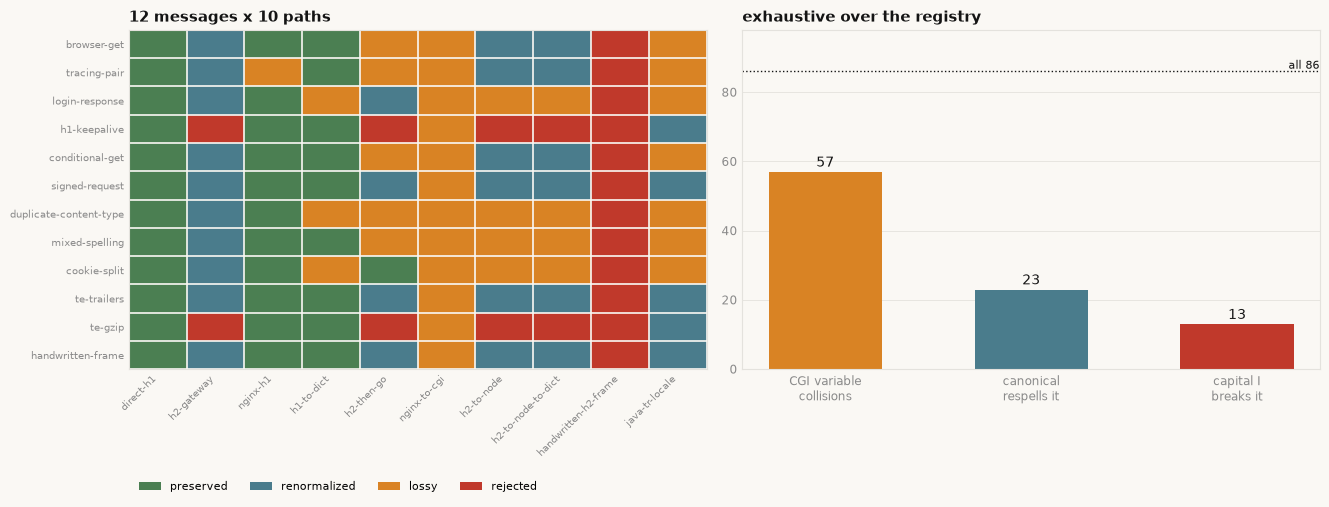

In [8]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

INK, MUTED, GRID, PAPER = "#141414", "#8a8a8a", "#e4e2dd", "#faf8f4"
COLOUR = {"preserved": "#4b7f52", "renormalized": "#4a7c8c",
          "lossy": "#d98324", "rejected": "#c0392b"}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13.4, 5.4))
fig.patch.set_facecolor(PAPER)

paths, msgs = list(PATHS), [m.name for m in CORPUS]
idx = {v: i for i, v in enumerate(VERDICTS)}
mat = np.array([[idx[grid[(m, p)]] for p in paths] for m in msgs], dtype=float)
ax1.imshow(mat, aspect="auto", vmin=-0.5, vmax=3.5,
           cmap=matplotlib.colors.ListedColormap([COLOUR[v] for v in VERDICTS]))
ax1.set_xticks(range(len(paths)))
ax1.set_xticklabels(paths, rotation=45, ha="right", fontsize=7)
ax1.set_yticks(range(len(msgs)))
ax1.set_yticklabels(msgs, fontsize=7.5)
for x in range(len(paths) + 1):
    ax1.axvline(x - 0.5, color=PAPER, lw=1.2)
for y in range(len(msgs) + 1):
    ax1.axhline(y - 0.5, color=PAPER, lw=1.2)
ax1.set_title(f"{len(msgs)} messages x {len(paths)} paths", loc="left",
              fontweight="bold", color=INK, fontsize=11)
ax1.legend(handles=[Patch(facecolor=COLOUR[v], label=v) for v in VERDICTS],
           loc="upper left", bbox_to_anchor=(0, -0.30), ncol=4, frameon=False,
           fontsize=8)
ax1.tick_params(length=0, colors=MUTED)

labels = ["CGI variable\ncollisions", "canonical\nrespells it",
          "capital I\nbreaks it"]
vals = [len(collisions), len(respelled), len(dotless)]
bars = ax2.bar(labels, vals, color=[COLOUR["lossy"], COLOUR["renormalized"],
                                    COLOUR["rejected"]], width=0.55)
ax2.axhline(len(REGISTRY), color=INK, ls=":", lw=1)
ax2.text(2.4, len(REGISTRY), f" all {len(REGISTRY)}", va="bottom", ha="right",
         fontsize=8, color=INK)
for b, v in zip(bars, vals):
    ax2.text(b.get_x() + b.get_width() / 2, v + 1.5, str(v), ha="center",
             fontsize=10, color=INK)
ax2.set_ylim(0, len(REGISTRY) + 12)
ax2.set_facecolor(PAPER)
ax2.grid(axis="y", color=GRID, lw=0.6)
ax2.set_axisbelow(True)
ax2.tick_params(length=0, colors=MUTED, labelsize=8.5)
for s in ax2.spines.values():
    s.set_color(GRID)
ax2.set_title("exhaustive over the registry", loc="left", fontweight="bold",
              color=INK, fontsize=11)
for s in ax1.spines.values():
    s.set_color(GRID)

fig.tight_layout()
fig.savefig("header_notebook.png", dpi=150, facecolor=PAPER)
plt.show()

## 9. What the independent build found

| verdict | meaning | is `headers[name]` correct? |
|---|---|---|
| `preserved` | arrived spelled as sent | yes |
| `renormalized` | same meaning, new bytes | only with a case-folded lookup |
| `lossy` | a field or a duplicate is gone | no, and there is no error to catch |
| `rejected` | treated as malformed | no message arrived |

Three things the searches say that an example could not:

1. **Every** hyphenated field name has a legal underscore twin that shares its CGI
   variable. nginx's `underscores_in_headers off` default is the only thing between
   that and a header a client can forge - so "turn it on to fix my missing header"
   is a security change, not a config tweak.
2. Canonicalisation is not the registry. A stack that title-cases cannot produce
   `ETag`, `WWW-Authenticate` or `Content-MD5`, and `str.title()` and Go's rule
   disagree with *each other* the moment a digit or an underscore appears.
3. Every field name containing a capital `I` is destroyed by a locale-sensitive
   lowercase, and the result is not a legal field name, so no correct lookup can
   recover it.

The last cell checks these numbers against the ones this repo publishes from
`headers.py`, which was written separately.

In [9]:
PUBLISHED = {
    "names": 86,
    "collisions": 57,
    "respelled": 23,
    "dotless": 13,
    "preserved": 33,
    "renormalized": 31,
    "lossy": 36,
    "rejected": 20,
}

independent = {
    "names": len(REGISTRY),
    "collisions": len(collisions),
    "respelled": len(respelled),
    "dotless": len(dotless),
    **{v: counts[v] for v in VERDICTS},
}

print(f"{'quantity':<16}{'published':>10}{'this notebook':>16}   agree")
for k, want in PUBLISHED.items():
    got = independent[k]
    print(f"{k:<16}{want:>10}{got:>16}   {'yes' if got == want else 'NO'}")

assert independent == PUBLISHED, (independent, PUBLISHED)
print("\nTwo implementations, written separately, agree on every count.")

quantity         published   this notebook   agree
names                   86              86   yes
collisions              57              57   yes
respelled               23              23   yes
dotless                 13              13   yes
preserved               33              33   yes
renormalized            31              31   yes
lossy                   36              36   yes
rejected                20              20   yes

Two implementations, written separately, agree on every count.


## 10. Try your own

Paste real headers from a request you care about - `curl -v`, browser devtools,
an access log - and see which paths keep them intact.

In [10]:
# Your own header block. One "Name: value" per line.
BLOCK = """
Host: api.example.com
X_Tenant_Id: acme
Content-Type: application/json
If-None-Match: "abc"
X-Request-ID: 7f3c
"""

mine = mk("mine", *[(ln.split(":", 1)[0].strip(), ln.split(":", 1)[1].strip())
                    for ln in BLOCK.strip().splitlines() if ":" in ln])
print(mine.show())
print()
for p in PATHS:
    arrived, ev = deliver(mine, p)
    print(f"{p:<22}{verdict(mine, arrived):<15}"
          f"{'-' if arrived is None else len(arrived.fields)} fields out")
    for hop, codename, detail in ev:
        if codename not in ("lowercased", "canonicalised"):
            print(f"    [{hop}] {codename}: {detail}")

print()
print("Per-name advice:")
for f in mine.fields:
    notes = []
    if "_" in f.name:
        notes.append("nginx drops it by default; CGI merges it with the `-` spelling")
    if turkish_lower(f.name) != ascii_lower(f.name):
        notes.append("has a capital I - a locale-sensitive lowercase mangles it")
    if go_canonical(f.name) != f.name:
        notes.append(f"a canonical stack respells it {go_canonical(f.name)!r}")
    print(f"  {f.name:<22}{'; '.join(notes) or 'nothing on the path will change it'}")

  Host: api.example.com
  X_Tenant_Id: acme
  Content-Type: application/json
  If-None-Match: "abc"
  X-Request-ID: 7f3c

direct-h1             preserved      5 fields out
h2-gateway            renormalized   5 fields out
nginx-h1              lossy          4 fields out
    [nginx] dropped-underscore: 'X_Tenant_Id' dropped silently
h1-to-dict            preserved      5 fields out
h2-then-go            lossy          5 fields out
    [go] reordered: Header.Write emits keys sorted
nginx-to-cgi          lossy          4 fields out
    [nginx] dropped-underscore: 'X_Tenant_Id' dropped silently
h2-to-node            renormalized   5 fields out
h2-to-node-to-dict    renormalized   5 fields out
handwritten-h2-frame  rejected       - fields out
    [h2-receiver] malformed-uppercase: 'Host' has an uppercase byte (RFC 9113 8.2.1)
java-tr-locale        lossy          5 fields out
    [locale] turkish-dotless-i: 'X_Tenant_Id' -> 'x_tenant_ıd', not 'x_tenant_id'
    [locale] turkish-dotless-i: 'I

---

**Day 149 of the [phoebe-the-builder](https://github.com/phoebefu6/phoebe-the-builder) catalogue.**

The engine this notebook checks itself against is
[`headers.py`](automation-suite/header-casing/headers.py) - 10 delivery paths, 8 hops, 86 field names,
54 tests. Run the interactive version:

```bash
pip install -r requirements.txt
streamlit run app.py
```

Related builds, same family of failure - the operation looks total and is not:
[`filename-sanitiser`](../filename-sanitiser/) (Day 146) on `casefold()` versus a
real case table, [`slug-collider`](../slug-collider/) (Day 144) on the collisions a
slugifier creates, and [`duration-parser`](../duration-parser/) (Day 147) on eight
conforming readings of one string.